# 06. Hfq を「限られた共有資源」として陽に入れる

> **出典**: Adamson DN, Lim HN (2011) *Essential Requirements for Robust Signaling in Hfq Dependent Small RNA Networks.* PLoS Comput Biol 7(8):e1002138.

02〜05 では sRNA と mRNA が直接出会って壊れ合う、と単純化していた。でも実際は、多くの sRNA は
RNA シャペロン **Hfq** に一度乗ってから標的 mRNA と対合する。そして **Hfq は数が限られた共有資源**。
この論文は「単一の sRNA-mRNA ペアが、Hfq 経由で効率よく・頑健に duplex を作れる条件」を問う。

## 反応網（単一ペア・独立結合＋RNA解離）

| 反応 | 意味 |
|---|---|
| $\varnothing\to s,\ \varnothing\to m$ | sRNA / mRNA 転写 |
| $s+H \rightleftharpoons sH,\ \ m+H \rightleftharpoons mH$ | Hfq への結合（会合 $k_a$ / 解離 $k_d$） |
| $sH+m \rightleftharpoons T,\ \ mH+s \rightleftharpoons T$ | 三者複合体 $T$ への2経路 |
| $T \to D + H$ | アニールして duplex 形成、**Hfq を放出**（$k_5$） |

全 RNA 種は分解($\beta$)し、複合体は分解時に Hfq を放出。**Hfq は合成も分解もされず、総量 $H_{tot}=H+sH+mH+T$ が保存**される。

**予想**: Hfq が少なすぎると複合体ができず duplex 0。多すぎると sRNA と mRNA が別々の singly-bound
複合体($sH,\ mH$)に**隔離**され、三者複合体ができず duplex 0。だから **duplex は Hfq に対して釣鐘状**になるはず。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

H, S, M, SH, MH, T, D = (Species(x) for x in ['H','s','m','sH','mH','T','D'])
A_S = A_M = 10.0    # 転写
BETA = 1.0          # 分解(全種共通)
KA = 1.0            # 会合(全結合共通 = 独立結合)
K5 = 10.0           # 三者複合体 -> duplex
SP = ['H','s','m','sH','mH','T','D']

def build(h_tot, kd):
    mdl = NetworkModel()
    for r in [ReactionRule([],[S],A_S), ReactionRule([],[M],A_M),
              ReactionRule([S],[],BETA), ReactionRule([M],[],BETA),
              ReactionRule([S,H],[SH],KA), ReactionRule([SH],[S,H],kd),
              ReactionRule([M,H],[MH],KA), ReactionRule([MH],[M,H],kd),
              ReactionRule([SH,M],[T],KA), ReactionRule([T],[SH,M],kd),
              ReactionRule([MH,S],[T],KA), ReactionRule([T],[MH,S],kd),
              ReactionRule([T],[D,H],K5),
              ReactionRule([SH],[H],BETA), ReactionRule([MH],[H],BETA),
              ReactionRule([T],[H],BETA), ReactionRule([D],[],BETA)]:
        mdl.add_reaction_rule(r)
    return mdl

def steady(h_tot, kd):
    ret = run_simulation(400.0, y0={'H': h_tot}, model=build(h_tot, kd),
                         solver='ode', ndiv=1, species_list=SP)
    return dict(zip(SP, ret.as_array()[-1][1:]))

def pct_duplex(h_tot, kd):
    v = steady(h_tot, kd); tot_m = v['m']+v['mH']+v['T']+v['D']
    return 100*v['D']/tot_m if tot_m > 0 else 0.0
print('model ready')

model ready


## Hfq を掃引する — 釣鐘と「解離が窓を広げる」効果

総 Hfq を対数で振り、標的 mRNA のうち duplex になった割合を測る。解離 $k_d$ が遅い場合(0.3)と速い場合(10)を比べる。

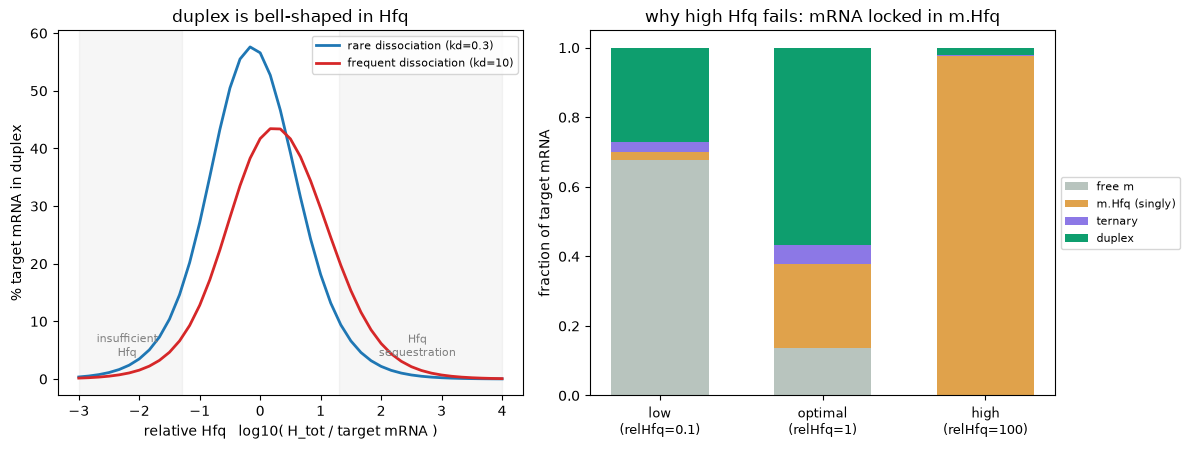

In [2]:
rel = np.logspace(-3, 4, 43)   # relative Hfq = H_tot / (a_m/beta)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

for kd, c, lab in [(0.3,'C0','rare dissociation (kd=0.3)'),
                   (10.0,'C3','frequent dissociation (kd=10)')]:
    y = np.array([pct_duplex(r*10, kd) for r in rel])
    ax1.plot(np.log10(rel), y, '-', color=c, lw=2, label=lab)
ax1.axvspan(-3,-1.3, color='gray', alpha=.07); ax1.axvspan(1.3,4, color='gray', alpha=.07)
ax1.text(-2.2,4,'insufficient\nHfq', ha='center', fontsize=8, color='gray')
ax1.text(2.6,4,'Hfq\nsequestration', ha='center', fontsize=8, color='gray')
ax1.set_xlabel('relative Hfq   log10( H_tot / target mRNA )')
ax1.set_ylabel('% target mRNA in duplex'); ax1.set_title('duplex is bell-shaped in Hfq'); ax1.legend(fontsize=8)

parts, part_lab = ['m','mH','T','D'], ['free m','m.Hfq (singly)','ternary','duplex']
cols = ['#b8c4be','#e0a24b','#8c78e6','#0e9e6e']
data = np.array([[ (lambda v: v[p]/(v['m']+v['mH']+v['T']+v['D']))(steady(r*10,0.3)) for p in parts]
                 for r in [0.1,1.0,100.0]])
bottom = np.zeros(3); x = np.arange(3)
for j,(pl,col) in enumerate(zip(part_lab,cols)):
    ax2.bar(x, data[:,j], bottom=bottom, color=col, label=pl, width=.6); bottom += data[:,j]
ax2.set_xticks(x); ax2.set_xticklabels(['low\n(relHfq=0.1)','optimal\n(relHfq=1)','high\n(relHfq=100)'], fontsize=9)
ax2.set_ylabel('fraction of target mRNA'); ax2.set_title('why high Hfq fails: mRNA locked in m.Hfq')
ax2.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0,0.5))
plt.tight_layout(); plt.show()

## 読み取り

- **左**: 予想どおり **duplex 形成は Hfq に対して釣鐘状**。少なすぎ（不足）でも多すぎ（隔離）でもダメで、中間に最適点がある。
  これが論文のいう「lower bound / upper bound」＝ Hfq がこの窓の中にあれば機能する、という **Hfq ロバスト性**。
- **右**: 高 Hfq でなぜ落ちるか。標的 mRNA のほとんどが **singly-bound の $m\cdot$Hfq に囚われ**、パートナー sRNA も
  別の $s\cdot$Hfq に囚われるので、三者複合体ができない。「資源が余っているのに機能が落ちる」逆説。
- **解離の効果**: $k_d$ を上げる（頻繁に外れる）と、ピークは下がるが**窓が高Hfq側へ広がる**（赤 > 青、relHfq≳3）。
  RNA が Hfq を何度も乗り換えられるので、隔離から抜け出しやすくなる = 論文の「frequent RNA dissociation increases robustness」。

**02〜05 との関係**: あれらの `m + s -> ∅` は、この網で **Hfq が潤沢で速い極限**をひとまとめにしたもの。
06 はその裏に隠れていた Hfq という共有資源を表に出した版。

## 練習問題

1. `K5`（duplex 形成の速さ）を上げると、釣鐘の高さと窓はどう動く？ 論文の「$k_5$ が Hfq recycling を速める」効果を確認。
2. sRNA と mRNA の転写量を非対称（例 `A_S=30, A_M=10`）にすると、最適 Hfq やピーク高はどうずれる？
3. [[bio-a_hfq-phylogenetics]] への接続: オーソログ間で Hfq への結合親和性（$k_a/k_d$）が違うなら、
   最適 Hfq 窓の位置・幅が変わる。系統ごとの $k_d$ 差を、この釣鐘の横ずれとして解釈してみる。
4. 協同的結合（例えば sH ができると mH の会合が速くなる）を1本追加して、窓が広がるか（論文 Fig.3-4）を試す。